In [1]:
using Markdown
using Printf
using Plots
using Statistics
using LinearAlgebra

In [2]:
function nested(d::Int, c::Vector{Float64}, x::Float64, xb::Vector{Float64} = zeros(d))
    if length(c) != d + 1
        error("Must have $(d+1) constants")
    end

    if length(xb) != d + 1
        error("Must have $(d+1) base points")
    end

    # string = "($(c[1]))"

    y = c[1]

    for i in 1:d
        y *= (x - xb[d - i + 1])
        y += c[i+1]
        # string = "($(c[i+1]) + (x - $(xb[d - i + 1]))" * string * ")"
    end


    return y
end

nested (generic function with 2 methods)

In [3]:
function newtonsInterpolation(x :: Vector{Float64}, y :: Vector{Float64}, divided_differences :: Vector{Vector{Float64}})
    start = length(divided_differences) == 0 ? 1 : length(divided_differences[1])

    if length(divided_differences) == 0
        push!(divided_differences, y)
    else
        divided_differences[1] = y
    end

    for i in start+1:length(x)
        push!(divided_differences, [])
    end

    curr_start = start;


    for i in 2:length(x)
        for j in curr_start:length(x) - i + 1
            divided_difference =  divided_differences[i-1][j + 1] - divided_differences[i - 1][j]
            push!(divided_differences[i], divided_difference/(x[j + i - 1] - x[j]))
        end

        if start != 1
            curr_start -= 1
        end
    end

    c = [divided_differences[length(divided_differences) - i + 1][1] for i in 1:length(divided_differences)]

    
    return divided_differences, (t::Float64) -> nested(length(x) - 1, c, t, x)
end

newtonsInterpolation (generic function with 1 method)

# Section 3.33. Computer problem 2:

Note: In practice the base points and the associated values to them would be precomputed and stored in memory to be accessed and not computed at runtime.

$f(x) = \cos(x)$

$0 \leq c \leq \pi/2$

$f(x) - f_{int} = \frac{\prod_{i = 1}^n (x - x_i)}{n!}f^{(n)}(c)$

$|f^{(n)}(c)| \leq 1$
$\prod_{i = 1}^n (x - x_i) = \frac{(\frac{\frac{\pi}{2} - 0}{2})^n}{2^{n-1}}T_n(x)$. $|T_n(x)| \leq 1 \implies |\prod_{i = 1}^n (x - x_i)| \leq \frac{\pi^n}{2^{3n-1}}$

Thus $|f(x) - f_{int}| \leq \frac{\pi^n}{2^{3n-1}n!} \leq 0.5 \times 10^{-n}$

Thus $n \geq 10$

In [17]:
function cos1(x::Float64)
    xb = chebyshevNodes(10, 0.0, pi/2)
    yb = cos.(xb)

    dd :: Vector{Vector{Float64}} = []
    dd, interpolant = newtonsInterpolation(xb, yb, dd)

    x = abs(x)

    x = x % 2pi
    sgn = 1
    
    if x > pi
        x = 2pi - x
    end

    if x > pi/2
        x = pi - x
        sgn = -1
    end

    return sgn * interpolant(x)
end

cos1 (generic function with 1 method)

In [18]:
function chebyshevNodes(n::Int, a::Float64 = -1.0, b::Float64 = 1.0)
    return [(b + a)/2 + ((b - a)/2)cos((2i - 1)pi/2n) for i in 1:n]
end

chebyshevNodes (generic function with 3 methods)

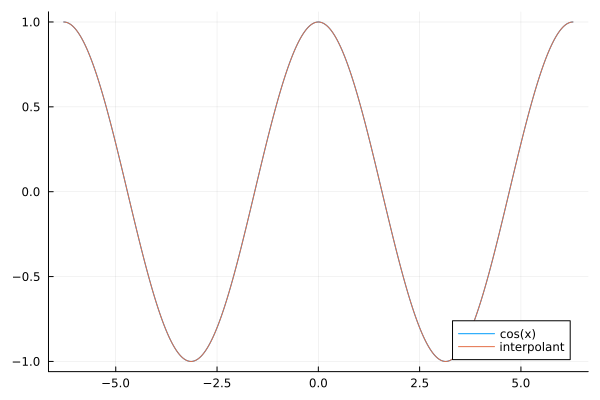

In [38]:
x = range(-2pi, 2pi, 1000)
error_func(x) = cos(x) - cos1(x)
plot(x,[cos, cos1], label=["cos(x)" "interpolant"])

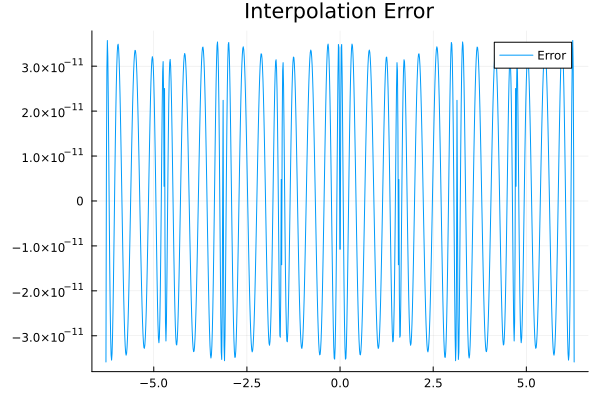

In [39]:
plot(x, error_func, label="Error", title="Interpolation Error")

In [29]:
estimate1 = cos1(10.0^4)
estimate2 = cos1(-10.0^4)
actual1 = cos(10^4)
actual2 = cos(-10^4)

-0.9521553682590148

In [34]:
Markdown.parse("
Interpolated value for ``x = 10^4``: $(estimate1)
    
Actual value for ``x = 10^4``: $(actual1)

Error: $(actual1 - estimate1)


Interpolated value for ``x = -10^4``: $(estimate1)
    
Actual value for ``x = -10^4``: $(actual1)

Error: $(actual1 - estimate1)
    ")

Interpolated value for $x = 10^4$: -0.9521553682246678

Actual value for $x = 10^4$: -0.9521553682590148

Error: -3.434696971282847e-11

Interpolated value for $x = -10^4$: -0.9521553682246678

Actual value for $x = -10^4$: -0.9521553682590148

Error: -3.434696971282847e-11
